## Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report ,confusion_matrix,accuracy_score
import pickle 

## Data collection and Processing


In [3]:
# Load the datasets to the pandas dataframe
rain_df = pd.read_csv('Downloads/Rainfall.csv')
rain_df

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7
...,...,...,...,...,...,...,...,...,...,...,...,...
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9


In [5]:
print(type(rain_df))   # we can get which type of data frame it is 

<class 'pandas.core.frame.DataFrame'>


In [6]:
rain_df.shape             # gives us about the number of rows and coloumns 

(366, 12)

In [7]:
rain_df.head()             # give us first five rows

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [8]:
rain_df.tail()  # give us last five rows 

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9
365,31,1026.4,20.5,17.8,15.5,13.0,74,66,no,5.7,20.0,23.3


In [9]:
rain_df['day'].unique()                 # month wise date 

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
      dtype=int64)

In [10]:
rain_df.info()                        # give the information whether about null vlalues and data type       

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [11]:
rain_df.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [12]:
# remove extra spaces in all columns
rain_df.columns = rain_df.columns.str.strip()

In [13]:
rain_df.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

In [14]:
rain_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            366 non-null    int64  
 1   pressure       366 non-null    float64
 2   maxtemp        366 non-null    float64
 3   temparature    366 non-null    float64
 4   mintemp        366 non-null    float64
 5   dewpoint       366 non-null    float64
 6   humidity       366 non-null    int64  
 7   cloud          366 non-null    int64  
 8   rainfall       366 non-null    object 
 9   sunshine       366 non-null    float64
 10  winddirection  365 non-null    float64
 11  windspeed      365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [15]:
# droping the day column
rain_df = rain_df.drop(columns=['day'])

In [16]:
rain_df

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7
...,...,...,...,...,...,...,...,...,...,...,...
361,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9


In [17]:
rain_df.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [18]:
 # NO OF THE MISSING VALUES
rain_df.isnull().sum()

pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    1
windspeed        1
dtype: int64

In [20]:

rain_df['winddirection'].unique()

array([ 80.,  50.,  40.,  20.,  30.,  60.,  70.,  10., 200., 220., 120.,
       190., 210., 300., 240., 180., 230.,  90., 170., 150., 100., 130.,
        nan, 160., 270., 280., 250., 260., 290., 350., 110., 140.])

In [21]:
# handling the missing values
rain_df['winddirection'] =rain_df['winddirection'].fillna(rain_df['winddirection'].mode()[0])
rain_df['windspeed']=rain_df['windspeed'].fillna(rain_df['windspeed'].median())

In [29]:
rain_df

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7
...,...,...,...,...,...,...,...,...,...,...,...,...
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,1,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,1,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,1,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,1,1.2,20.0,20.9


In [22]:
rain_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pressure       366 non-null    float64
 1   maxtemp        366 non-null    float64
 2   temparature    366 non-null    float64
 3   mintemp        366 non-null    float64
 4   dewpoint       366 non-null    float64
 5   humidity       366 non-null    int64  
 6   cloud          366 non-null    int64  
 7   rainfall       366 non-null    object 
 8   sunshine       366 non-null    float64
 9   winddirection  366 non-null    float64
 10  windspeed      366 non-null    float64
dtypes: float64(8), int64(2), object(1)
memory usage: 31.6+ KB


In [23]:
rain_df.isnull().sum()

pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64

In [24]:
rain_df['rainfall'].unique()

array(['yes', 'no'], dtype=object)

In [25]:
# converting the string to float yes =1 and no =0 
rain_df['rainfall'] = rain_df['rainfall'].map({"yes":1,"no":0})

In [26]:
rain_df

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7
...,...,...,...,...,...,...,...,...,...,...,...
361,1022.7,18.8,17.7,16.9,15.0,84,90,1,0.0,30.0,18.4
362,1026.6,18.6,17.3,16.3,12.8,75,85,1,1.0,20.0,25.9
363,1025.9,18.9,17.7,16.4,13.3,75,78,1,4.6,70.0,33.4
364,1025.3,19.2,17.3,15.2,13.3,78,86,1,1.2,20.0,20.9


## EXPLORATARY DATA ANAYLSIS

In [27]:
rain_df.shape

(366, 11)

In [28]:
# setting plot style for all the plots
sns.set(style="whitegrid")

In [29]:
rain_df.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,0.680328,4.419399,101.284153,21.534153
std,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,0.466988,3.934398,81.722827,10.056054
min,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,0.000000,10.000000,4.400000
25%,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.000000,0.500000,40.000000,13.725000
50%,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,1.000000,3.500000,70.000000,20.500000
75%,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,1.000000,8.200000,190.000000,27.825000
max,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,1.000000,12.100000,350.000000,59.500000


In [30]:
rain_df.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

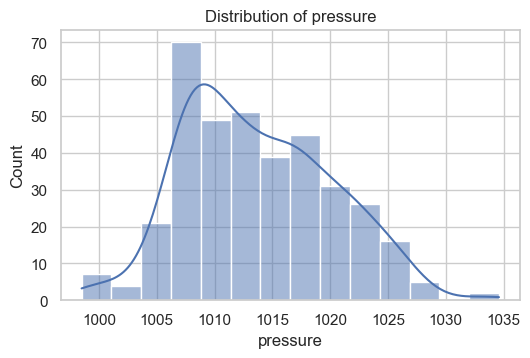

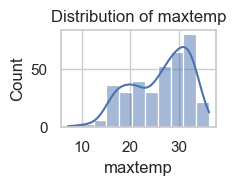

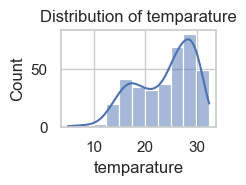

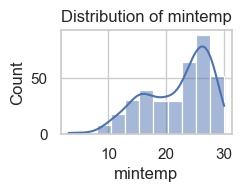

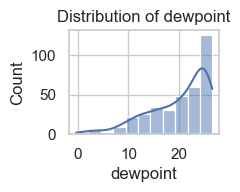

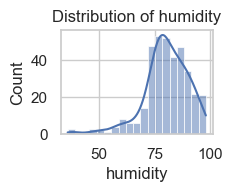

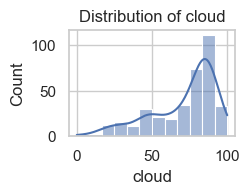

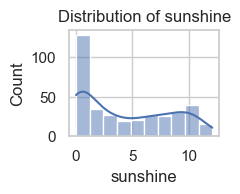

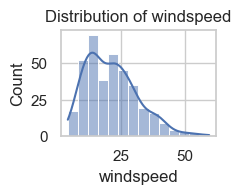

In [31]:
plt.figure (figsize=(15,10))
for i,column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine', 'windspeed'],1):
    plt.subplot(3,3,i)
    sns.histplot(rain_df[column],kde= True)
    plt.title(f"Distribution of {column}")
    plt.tight_layout()
    plt.show()

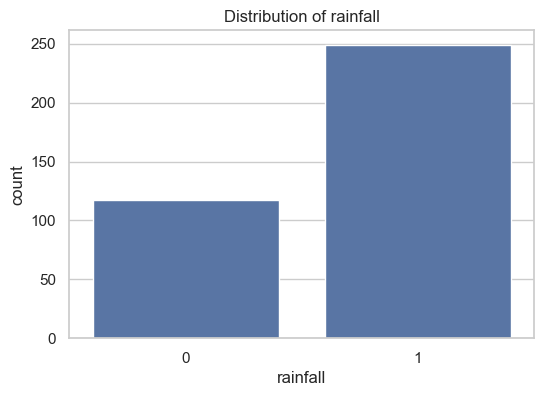

In [32]:
#Distribution of the rainfall to now the class is balance
plt.figure(figsize=(6,4))
sns.countplot(x="rainfall",data =rain_df)
plt.title('Distribution of rainfall')
plt.show()

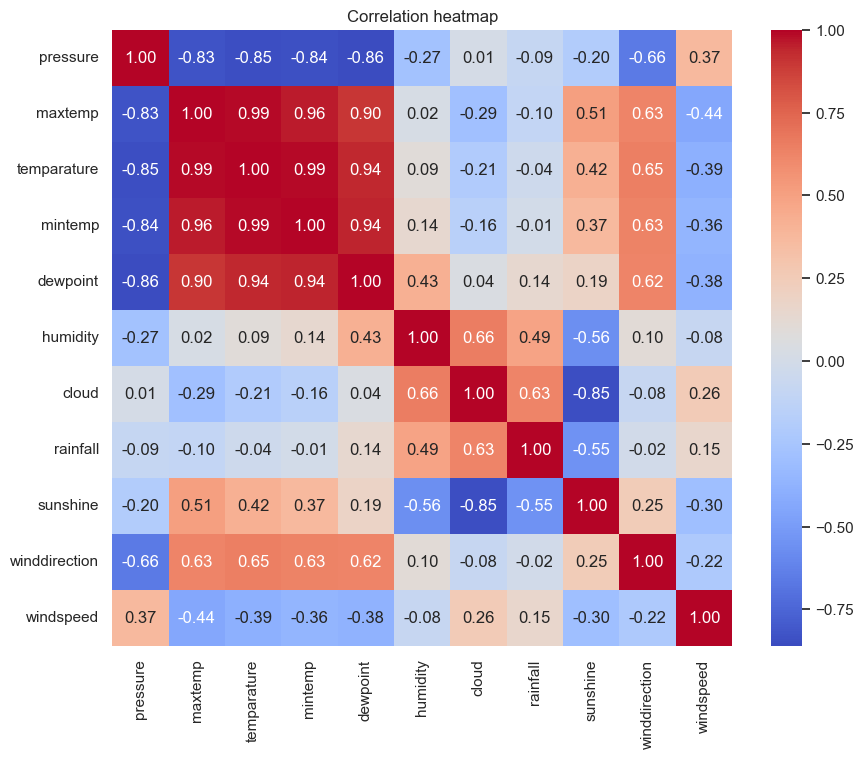

In [33]:
# correlation matri
plt.figure(figsize =(10,8))
sns.heatmap(rain_df.corr(),annot=True ,cmap="coolwarm",fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

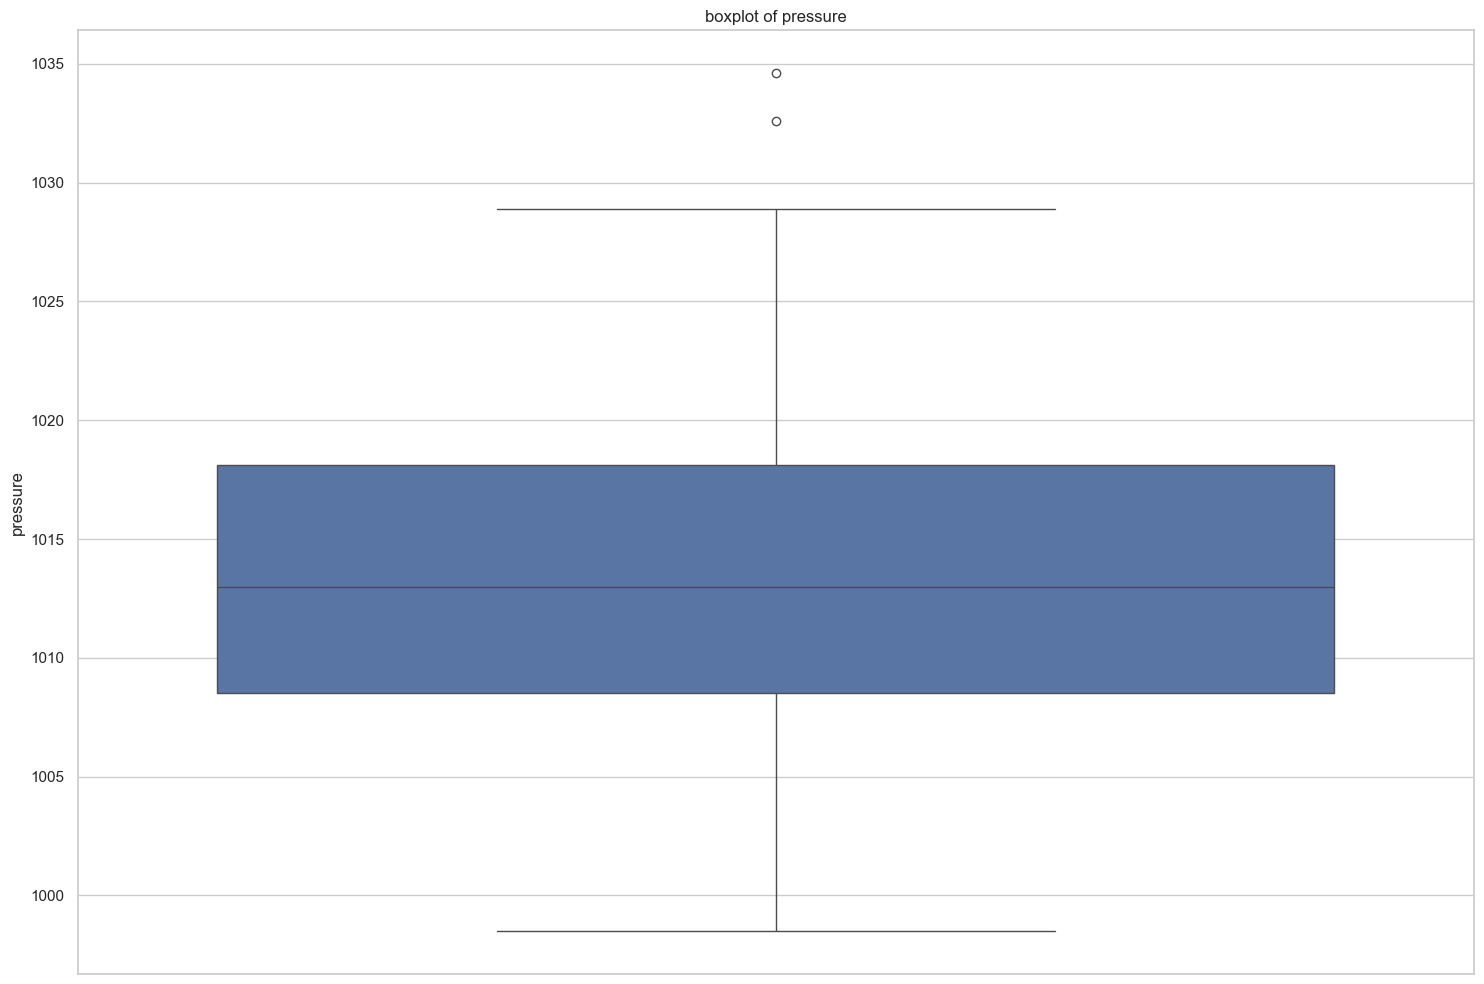

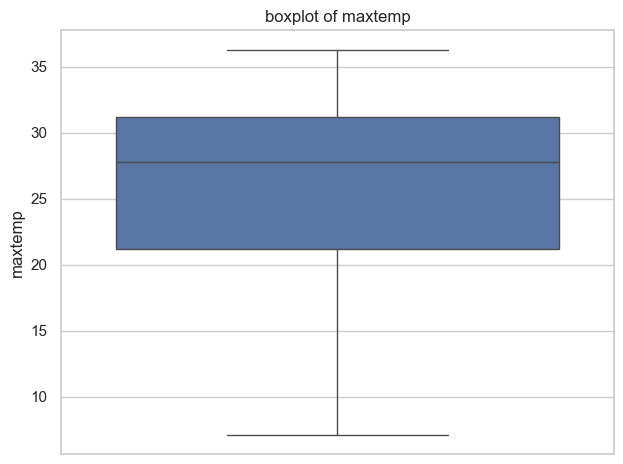

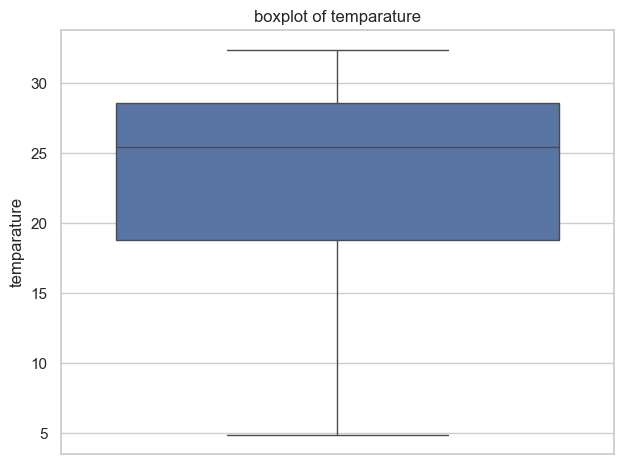

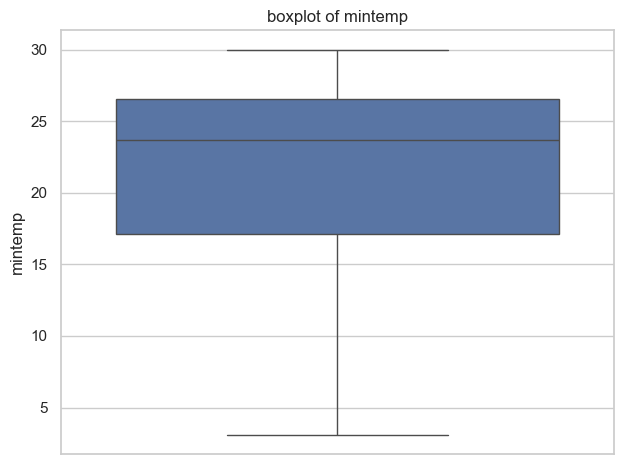

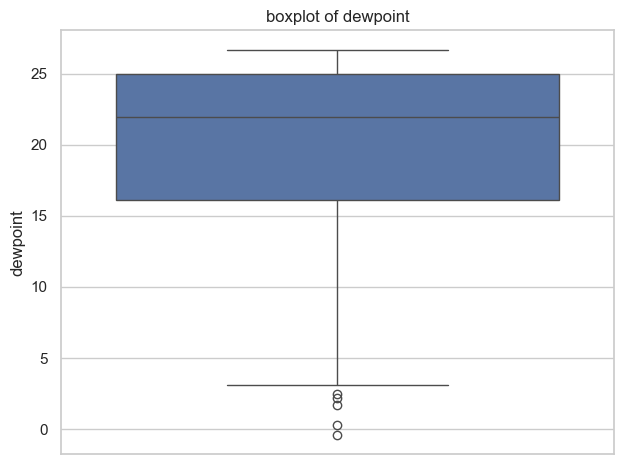

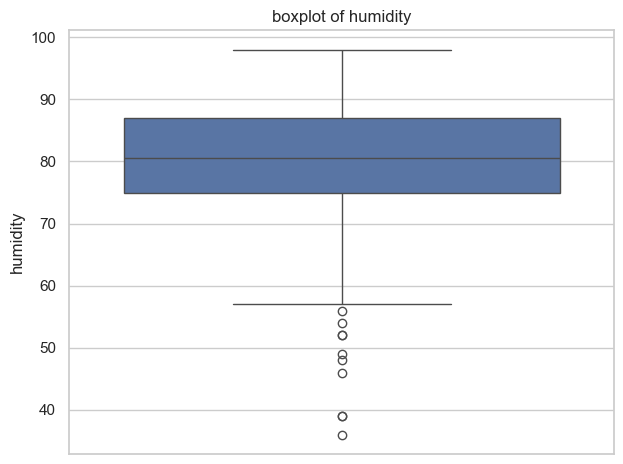

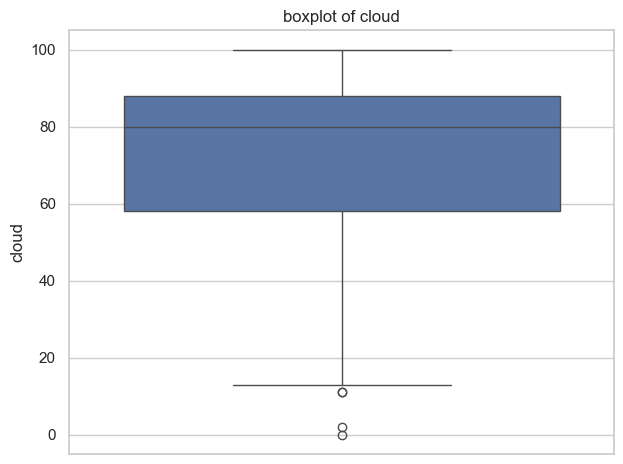

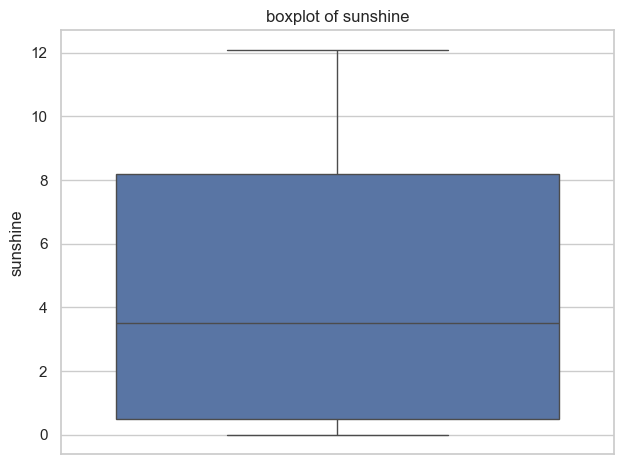

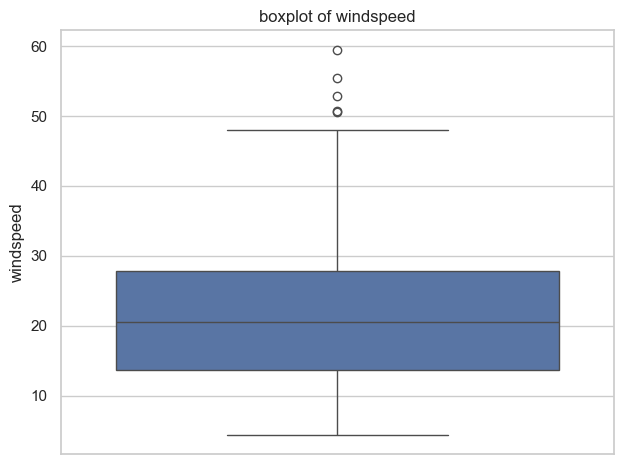

In [34]:
plt.figure (figsize=(15,10))
for i,column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine', 'windspeed'],1):
   
    sns.boxplot(rain_df[column])
    plt.title(f"boxplot of {column}")
    plt.tight_layout()
    plt.show()

## Data Preprocessing

In [35]:
# drop highly correleated columns
rain_df =rain_df.drop(columns=['maxtemp', 'temparature', 'mintemp'])

In [36]:
rain_df.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,19.9,95,81,1,0.0,40.0,13.7


In [37]:
rain_df["rainfall"].value_counts()

rainfall
1    249
0    117
Name: count, dtype: int64

In [38]:
# DOWNFALL IN RAINFALL BETWEEN THE YES AND NO ,SEPARATE THE MAJORITY AND MINIORTY CLASS 
df_majority =rain_df[rain_df['rainfall']==1]
df_minority =rain_df[rain_df['rainfall']==0]
print(df_majority.shape)
print(df_minority.shape)

(249, 8)
(117, 8)


In [39]:
# downsample majority class to match miniority class
df_majority_downsampled = resample(df_majority,replace=False,n_samples=len(df_minority),random_state =42)

In [40]:
df_majority_downsampled.shape

(117, 8)

In [41]:
# df_majority_downsampled concentate with miniority downsample
df_downsampled =pd.concat([df_majority_downsampled,df_minority])

In [42]:
df_downsampled.shape

(234, 8)

In [43]:
df_downsampled.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
188,1005.9,25.6,77,53,1,10.5,270.0,11.3
9,1017.5,15.5,85,91,1,0.0,70.0,37.7
137,1012.3,20.1,80,86,1,0.3,80.0,39.5
89,1018.3,16.3,79,89,1,2.4,40.0,14.8
157,1008.8,24.7,91,80,1,2.2,20.0,11.2


In [44]:
# shuffling the final datasample
df_downsampled = df_downsampled.sample(frac =1,random_state = 42).reset_index(drop =True)

In [45]:
df_downsampled['rainfall'].value_counts()

rainfall
1    117
0    117
Name: count, dtype: int64

## Spilting the data into training data and test data

In [46]:
# splits the features and targets in X and y
X= df_downsampled.drop(columns =['rainfall'])
y=df_downsampled['rainfall']

In [47]:
X

,pressure,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1022.2,14.1,78,90,0.0,30.0,28.5
1,1013.4,19.5,69,17,10.5,70.0,12.4
2,1006.1,24.4,74,27,10.8,220.0,8.7
3,1007.6,24.8,85,84,1.8,70.0,34.8
4,1021.2,8.4,66,18,10.1,20.0,24.4
...,...,...,...,...,...,...,...
229,1008.1,25.4,86,75,5.7,20.0,9.5
230,1010.1,19.9,91,89,0.0,70.0,31.8
231,1020.6,14.7,91,88,0.3,50.0,24.4
232,1008.3,24.1,74,29,5.7,10.0,4.4


In [48]:
y

0      1
1      0
2      0
3      1
4      0
      ..
229    1
230    1
231    1
232    0
233    1
Name: rainfall, Length: 234, dtype: int64

In [49]:
# splitting the data into training and testing
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

## ModelTraining

In [50]:
#Hyperparameter tunning
rf_model =RandomForestClassifier(random_state=42)
param_grid_rf ={
                 "n_estimators":[50,100,200],
                "max_features":["sqrt","log2"],
                 "max_depth": [None,10,20,30],
                 "min_samples_split":[2,5,10],
                 "min_samples_leaf":[1,2,4]
}

In [51]:
# Hyperparameter tunning using GridsearchCV
grid_search_rf =GridSearchCV(estimator=rf_model,param_grid= param_grid_rf,cv =5 ,n_jobs =-1 ,verbose =2)
grid_search_rf.fit(X_train,y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [74]:
best_rf_model =grid_search_rf.best_estimator_
print("best parameters for Random Forest:",grid_search_rf.best_params_)


best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}


## Model Evaluation

In [75]:
cv_scores = cross_val_score(best_rf_model,X_train,y_train,cv=5)
print("Cross-Validation scores ",cv_scores)
print("Mean cross-validation score :",np.mean(cv_scores))

Cross-Validation scores  [0.68421053 0.81578947 0.83783784 0.83783784 0.91891892]
Mean cross-validation score : 0.818918918918919


In [76]:
# test set performance
y_pred = best_rf_model.predict(X_test)
print("Test set Accuracy",accuracy_score(y_test,y_pred))
print("Test set confusion Matrix\n",confusion_matrix(y_test ,y_pred))
print("classification Report:\n",classification_report(y_test,y_pred))

Test set Accuracy 0.7446808510638298
Test set confusion Matrix
 [[17  7]
 [ 5 18]]
classification Report:
               precision    recall  f1-score   support

           0       0.77      0.71      0.74        24
           1       0.72      0.78      0.75        23

    accuracy                           0.74        47
   macro avg       0.75      0.75      0.74        47
weighted avg       0.75      0.74      0.74        47



## prediction on unknown data

In [68]:
X_train.columns

Index(['pressure', 'dewpoint', 'humidity', 'cloud', 'sunshine',
       'winddirection', 'windspeed'],
      dtype='object')

In [88]:
input_rain_df   = (1008.1,25.4	,86	,75	,5.7	,20.0,	9.5)
input_df =pd.DataFrame([input_rain_df],columns=['pressure', 'dewpoint', 'humidity', 'cloud', 'sunshine',
       'winddirection', 'windspeed'])
prediction =best_rf_model.predict(input_df)

In [89]:
input_df

,pressure,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1008.1,25.4,86,75,5.7,20.0,9.5


In [90]:
prediction =best_rf_model.predict(input_df)
print(prediction)

[1]


In [91]:
prediction =best_rf_model.predict(input_df)
print("prediction results:","rainfall" if prediction[0]==1 else "no rainfall")

prediction results: rainfall


In [92]:
# save model and features names to a pickle 
model_data ={"model": best_rf_model,"feature_names": X.columns.tolist()}
with open("rainfall prediction.pkl","wb") as file:
    pickle .dump(model_data ,file)


## load the saved model and file and use it for prediction

In [93]:
import pandas as pd
import pickle

In [94]:
# load the trained model and features names from the pickle file
with open("rainfall prediction.pkl","rb") as file:
 model_data =pickle.load(file)

In [95]:
model = model_data["model"]
feature_names =model_data["feature_names"]

In [96]:
input_rain_df   = (1015.9,19.9,95,81,0.0,40.0,13.7)
input_df =pd.DataFrame([input_rain_df],columns= feature_names)

In [97]:
prediction =best_rf_model.predict(input_df)
print("prediction results:","rainfall" if prediction[0]==1 else "no rainfall")

prediction results: rainfall
